In [1]:
# Import Packages
import os
import re
import sys
import time
import copy
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, GroupKFold

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV

from sklearn.feature_selection import VarianceThreshold

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

!chmod 644 ~/.local/share/jupyter/history.sqlite
#!rm ~/.local/share/jupyter/history.sqlite

chmod: /Users/kosaraju_b/.local/share/jupyter/history.sqlite: No such file or directory


In [2]:
#%load_ext autoreload
#%reload_ext autoreload
#%autoreload 2
#from model_functions import *

%run Model_functions.ipynb

# EMIT FULL BANDS DATA

In [7]:
#EMIT_DATA_CSV         = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/AGB_EO_EMIT.csv"
EMIT_DATA_CSV         = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/AGB_EMIT_EO_CANOPY.csv"
#EMIT_MISSING_DATA_CSV = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/AGB_EO_EMIT_MISSING.csv"

In [8]:
emit_df = pd.read_csv(EMIT_DATA_CSV)
print(emit_df.shape)

(3880, 316)


## DATA PREPROCESSING

### Select feature columns

In [9]:
non_feature_cols = [
    'dataset',             # metadata
    'EMIT_selected_date',  # metadata
    'EMIT_granule',        # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    'latitude',            # coordinate
    'longitude',           # coordinate
    'plant_AGB_kg',        # Target variable
    'diameter',            # Allometric
    'height'               # Allometric
]
target = 'plant_AGB_kg'

feature_cols = [c for c in emit_df.columns if c not in non_feature_cols]

X = emit_df[feature_cols]
y = emit_df[target]

X = X.rename({'tandemx_height_m': 'height'}, axis=1)

print(f"Features : {len(feature_cols)}")
print(f"Rows     : {len(emit_df)}")

Features : 304
Rows     : 3880


### Handle EMIT columns with NULL data

In [10]:
X = handle_null_columns(X)

Total NULL count           : 17604
Rows with at least one NULL: 1467
Total rows                 : 3880
Percentage                 : 37.8%

NULL count per column in affected rows:
EMIT_R1327    1467
EMIT_R1432    1467
EMIT_R1335    1467
EMIT_R1342    1467
EMIT_R1350    1467
EMIT_R1417    1467
EMIT_R1424    1467
EMIT_R1357    1467
EMIT_R1774    1467
EMIT_R1781    1467
EMIT_R1789    1467
EMIT_R1796    1467
dtype: int64
Dropping 12 columns:
['EMIT_R1327', 'EMIT_R1335', 'EMIT_R1342', 'EMIT_R1350', 'EMIT_R1357', 'EMIT_R1417', 'EMIT_R1424', 'EMIT_R1432', 'EMIT_R1774', 'EMIT_R1781', 'EMIT_R1789', 'EMIT_R1796']

NULL count after dropping: 0


These 12 bands are all in the 1300–1800 nm range — the shortwave infrared (SWIR) region. EMIT masks out specific wavelength ranges that are dominated by atmospheric water vapor absorption, where the signal is unreliable. The two main atmospheric water vapor absorption windows in EMIT are:  

~1340 to 1460 nm  ← water vapor absorption band  
~1780 to 1970 nm  ← water vapor absorption band  

All of the 12 null columns listed above, fall squarely in these two ranges. EMIT sets these to nodata for pixels where atmospheric correction failed or where the absorption is too strong to recover reliable surface reflectance.  

The above bands are unreliable by design. Drop them.

In [11]:
%run Model_functions.ipynb

### Remove Low Variance Features (cols)

In [14]:
X = remove_low_variance_cols(X,
                             exclude_cols=['height'],
                             threshold=0.01,
                             debug=False,
                             exclude_categorical=True)
assert X is not None

Total low variance columns removed: 99
Features after variance filtering: 292


### Remove Features With Weak Correlation to Target

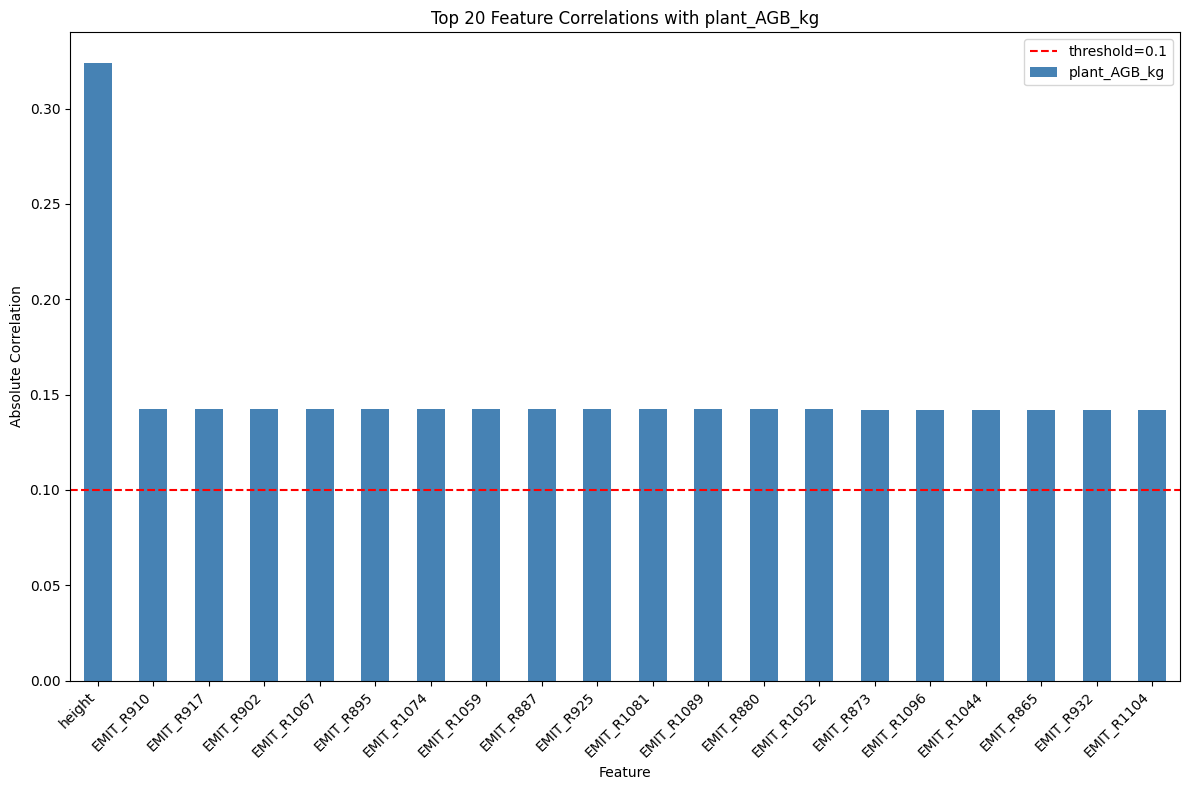

height        0.323760
EMIT_R910     0.142650
EMIT_R917     0.142640
EMIT_R902     0.142625
EMIT_R1067    0.142605
EMIT_R895     0.142586
EMIT_R1074    0.142544
EMIT_R1059    0.142453
EMIT_R887     0.142436
EMIT_R925     0.142428
EMIT_R1081    0.142380
EMIT_R1089    0.142266
EMIT_R880     0.142257
EMIT_R1052    0.142205
EMIT_R873     0.142132
EMIT_R1096    0.142024
EMIT_R1044    0.142020
EMIT_R865     0.141829
EMIT_R932     0.141771
EMIT_R1104    0.141661
Name: plant_AGB_kg, dtype: float64


In [15]:
numerical_cols = get_numerical_cols(X)

target_corr = plot_correlation_matrix(X[numerical_cols],
                                      y,
                                      top_n=20)
print(target_corr)

**Remove uncorrelated numerical columns**

In [17]:
corr_threshold = 0.1
X = remove_uncorrelated_numerical_cols(X, y,
                                       threshold=corr_threshold,
                                       exclude_cols=['height'])
assert X is not None

Weak correlations removed: ['EMIT_R1692', 'EMIT_R1685', 'EMIT_R2190', 'EMIT_R2182', 'EMIT_R1677', 'EMIT_R760', 'EMIT_R2175', 'EMIT_R954', 'EMIT_R1476', 'EMIT_R857', 'EMIT_R1051', 'EMIT_R1729', 'CIrededge', 'EMIT_R1610', 'EMIT_R1454', 'EMIT_R1462', 'EMIT_R1148', 'EMIT_R1447', 'simard_height_m', 'EMIT_R1245', 'NBR', 'NDRE1', 'EMIT_R1469', 'EMIT_R1989', 'EMIT_R969', 'EMIT_R2485', 'NDVI', 'EMIT_R775', 'EMIT_R1439', 'EMIT_R1066', 'EMIT_R872', 'EVI']

Total features after correlation filtering: 161


In [18]:
X = remove_uncorrelated_categorical_cols(X, y)
assert X is not None


--- plot_id ---
Variable  : plot_id
F-stat    : 21.7921
p-value   : 0.0000
Relevant? : True

--- species ---
Variable  : species
F-stat    : 45.2611
p-value   : 0.0000
Relevant? : True

   feature  relevant?
0  plot_id       True
1  species       True


Strong correlations kept   : 161
Weak correlations removed: 0


### Convert categorical variables to one-hot encoding

In [19]:
# Retain the groups/plot_id for splitting the data based on groups.
groups = X['plot_id'].copy()

In [20]:
categorical_cols = get_categorical_cols(X)
print(f"Categorical columns: {categorical_cols}")

X = pd.get_dummies(X, columns=categorical_cols, dtype=int)

Categorical columns: ['plot_id', 'species']


# LINEAR REGRESSION

In [25]:
linear_reg_experiments = {}
cv = 5

## Linear regression model with structural variables only.

### Linear regression modeling with all of the structural variables excluding plot_id variable.

In [32]:
label_1 = "Structural variables without plot_id"

emit_cols  = [c for c in X.columns if c.startswith('EMIT')]
plot_cols  = [c for c in X.columns if c.startswith('plot_id')]
other_cols = [c for c in X.columns if c not in emit_cols and c not in plot_cols]
print(f"Features: {other_cols}")
X_struct_wo_plot = X[other_cols]

results = linear_reg_groups("regular",
                            X_struct_wo_plot, y,
                            cv=cv, groups=groups,
                            label=label_1,
                            display=True,
                            is_stratified=False)
results["X_data"] = X_struct_wo_plot.copy()
results["Features"] = other_cols

linear_reg_experiments["LIN: " + label_1] = results

Features: ['MSI', 'height', 'species_Avicennia germinans', 'species_Laguncularia racemosa', 'species_Rhizophora mangle']

 Structural variables without plot_id, ALGO: LINEAR REGRESSION: 
Test R²     : 0.2498
Test RMSE   : 4.00 kg
Train R² (log scale): 0.2887
Train R² (orig scale): -0.0165
Train RMSE  : 18.72 kg
Num rows    : 3100
Num Features: 5

 Cross-validation ---
CV R² mean: 0.1798
CV R² std : 0.2150
CV scores : [-0.023  0.587  0.193  0.062  0.08 ]

Grouped Cross-validation ---
Grouped CV R² mean: -142.3702
Grouped CV R² std : 652.1427
Grouped CV scores : [-4.650000e-01 -3.059170e+02 -6.191700e+01 -2.810000e-01 -4.542400e+01
 -1.183900e+01 -8.808600e+01 -1.640000e-01 -6.400000e-02 -3.800000e-02
 -2.666800e+01 -8.300000e-02  1.390000e-01 -5.000000e-02 -1.000000e-03
  5.500000e-02 -1.600000e-02 -2.280000e-01 -5.960000e-01 -6.570000e-01
 -4.368342e+03  1.400000e-01 -2.180100e+01  7.900000e-02 -5.000000e-02
 -2.180000e-01  1.580000e-01 -1.290000e-01 -2.400000e-02  5.900000e-02
 -2.840

### Linear regression modeling with all of the structural variables including plot_id variable.

In [31]:
label_2 = "Structural variables + plot_id"

emit_cols  = [c for c in X.columns if c.startswith('EMIT')]
other_cols = [c for c in X.columns if c not in emit_cols]
X_struct_wi_plot = X[other_cols]

results = linear_reg_groups("regular",
                            X_struct_wi_plot, y,
                            cv=cv, groups=groups,
                            label=label_2,
                            display=True,
                            is_stratified=False)
results["X_data"] = X_struct_wi_plot.copy()
results["Features"] = other_cols
linear_reg_experiments["LIN: " + label_2] = results


 Structural variables + plot_id, ALGO: LINEAR REGRESSION: 
Test R²     : 0.0917
Test RMSE   : 4.40 kg
Train R² (log scale): 0.4303
Train R² (orig scale): 0.1770
Train RMSE  : 16.85 kg
Num rows    : 3100
Num Features: 64

 Cross-validation ---
CV R² mean: 0.0731
CV R² std : 0.1893
CV scores : [ 0.047  0.368  0.179 -0.044 -0.185]

Grouped Cross-validation ---
Grouped CV R² mean: -330.8652
Grouped CV R² std : 1423.9016
Grouped CV scores : [-2.410000e-01 -7.902080e+02 -1.651370e+02 -3.240000e-01 -1.474550e+02
 -3.942700e+01 -2.747130e+02 -1.020000e-01 -4.400000e-02 -5.200000e-02
 -7.863000e+01 -6.810000e-01  1.370000e-01 -8.500000e-02 -1.500000e-02
 -2.110000e-01  2.100000e-02 -2.500000e-01 -2.470000e-01 -1.252000e+00
 -9.438681e+03  1.380000e-01 -7.137300e+01  7.400000e-02 -9.000000e-02
 -2.260000e-01  1.650000e-01 -1.350000e-01 -7.100000e-02  1.050000e-01
 -1.449000e+00 -7.150000e-01 -1.733990e+03  4.100000e-02 -9.400000e-01
 -1.524000e+00 -3.360000e-01  3.500000e-02 -2.753039e+03 -1.47

### Linear regression modeling with structural variables and interaction terms.

In [34]:
X_int = X_struct_wo_plot.copy(deep=True)
species_cols = [c for c in X.columns if c.startswith('species_')]

# Create interaction terms
for species_col in species_cols:
    if 'diameter' in X_int.columns:
        X_int[f'diameter_x_{species_col}'] = X_int['diameter'] * X_int[species_col]
    X_int[f'height_x_{species_col}']   = X_int['height']   * X_int[species_col]

if 'diameter' in X_int.columns:
    X_int['diameter_x_height'] = X_int['diameter'] * X_int['height']

print(f"Features after adding interaction terms: {len(X_int.columns)}")
print(f"Interaction terms added: {len(species_cols) * 2 + 1}")

label_3 = "Structural variables + interaction terms"
results = linear_reg_groups("regular",
                            X_int, y,
                            cv=cv, groups=groups,
                            label=label_3,
                            display=True,
                            is_stratified=False)
results["X_data"] = X_int.copy()
results["Features"] = X_int.columns
linear_reg_experiments["LIN: " + label_3] = results

Features after adding interaction terms: 8
Interaction terms added: 7

 Structural variables + interaction terms, ALGO: LINEAR REGRESSION: 
Test R²     : 0.2415
Test RMSE   : 4.02 kg
Train R² (log scale): 0.2903
Train R² (orig scale): -0.0720
Train RMSE  : 19.23 kg
Num rows    : 3100
Num Features: 8

 Cross-validation ---
CV R² mean: 0.1492
CV R² std : 0.2186
CV scores : [-0.052  0.553  0.194  0.065 -0.013]

Grouped Cross-validation ---
Grouped CV R² mean: -203.0998
Grouped CV R² std : 1010.8073
Grouped CV scores : [-4.670000e-01 -2.790680e+02 -5.613000e+01 -2.700000e-01 -4.032500e+01
 -1.152600e+01 -7.831400e+01 -1.580000e-01 -4.700000e-02 -4.300000e-02
 -2.389300e+01 -1.140000e-01  1.360000e-01 -5.600000e-02  2.000000e-03
  2.600000e-02 -9.000000e-03 -2.190000e-01 -5.790000e-01 -6.810000e-01
 -6.865432e+03  1.400000e-01 -1.927700e+01  6.700000e-02 -1.010000e-01
 -2.140000e-01  1.580000e-01 -1.320000e-01 -5.400000e-02  7.600000e-02
 -4.880000e-01 -1.590000e-01 -6.077510e+02  4.100000e

## Linear regression modeling with EMIT bands only

In [35]:
label_4 = "EMIT bands only"

emit_cols  = [c for c in X.columns if c.startswith('EMIT')]
X_emit_bands = X[emit_cols]

results = linear_reg_groups("regular",
                            X_emit_bands, y,
                            cv=cv, groups=groups,
                            label=label_4,
                            display=True,
                            is_stratified=False)
results["X_data"] = X_emit_bands.copy()
results["Features"] = emit_cols
linear_reg_experiments["LIN: " + label_4] = results


 EMIT bands only, ALGO: LINEAR REGRESSION: 
Test R²     : 0.2179
Test RMSE   : 4.08 kg
Train R² (log scale): 0.3637
Train R² (orig scale): 0.1458
Train RMSE  : 17.16 kg
Num rows    : 3100
Num Features: 157

 Cross-validation ---
CV R² mean: -1.3580
CV R² std : 2.8504
CV scores : [-3.000e-03  5.250e-01 -3.300e-02 -2.430e-01 -7.036e+00]

Grouped Cross-validation ---
Grouped CV R² mean: -9.8602
Grouped CV R² std : 44.2339
Grouped CV scores : [-1.13500e+00 -1.45470e+02 -1.80000e-01 -0.00000e+00 -1.89990e+01
 -4.99900e+00 -6.10000e-02 -9.70000e-02 -6.00000e-03 -1.70000e-02
 -4.50000e-02 -3.75800e+00 -2.70000e-02 -3.50000e-02 -7.60000e-02
 -6.01000e-01 -8.60000e-02 -0.00000e+00 -4.32000e-01 -5.04000e-01
 -6.16000e-01 -3.40000e-02 -1.34000e-01 -1.41000e-01 -5.00000e-03
 -1.57000e-01 -1.30000e-02 -2.24000e-01 -1.20000e-01 -5.69000e-01
 -2.47000e-01 -4.40000e-01 -2.86000e-01 -5.80000e-02 -6.60000e-01
 -2.33000e-01 -7.47000e-01 -4.28000e-01 -2.73769e+02 -4.50000e-02
 -9.55000e-01 -1.12100e+00 -

## Linear regression modeling with all of the variables

### Linear regression modeling with all of the variables excluding "plot_id" variable.

In [36]:
label_5 = "All variables (structural + EMIT) without plot_id"

plot_cols  = [c for c in X.columns if c.startswith('plot_id_')]
other_cols = [c for c in X.columns if c not in plot_cols]
X_full_without_plot = X[other_cols]

results = linear_reg_groups("regular",
                            X_full_without_plot, y,
                            cv=cv, groups=groups,
                            label=label_5,
                            display=True,
                            is_stratified=False)
results["X_data"] = X_full_without_plot.copy()
results["Features"] = other_cols
linear_reg_experiments["LIN: " + label_5] = results


 All variables (structural + EMIT) without plot_id, ALGO: LINEAR REGRESSION: 
Test R²     : 0.3226
Test RMSE   : 3.80 kg
Train R² (log scale): 0.4067
Train R² (orig scale): 0.1647
Train RMSE  : 16.97 kg
Num rows    : 3100
Num Features: 162

 Cross-validation ---
CV R² mean: -57.6689
CV R² std : 110.2532
CV scores : [-3.44400e+00 -3.52900e+00 -2.01000e-01 -3.01000e+00 -2.78162e+02]

Grouped Cross-validation ---
Grouped CV R² mean: -154.2548
Grouped CV R² std : 537.1044
Grouped CV scores : [-5.400000e-01 -7.363160e+02 -1.900000e-02 -1.310000e-01 -3.197590e+02
 -7.513100e+01 -1.489000e+00 -1.926000e+00 -1.140000e-01 -8.500000e-01
 -2.030000e-01 -3.462200e+01  1.370000e-01  8.000000e-02 -6.370000e-01
 -8.980000e-01 -1.170000e-01 -5.000000e-02 -4.570000e-01 -4.100000e-01
 -2.682249e+03  1.520000e-01 -4.000000e-02 -6.400000e-02 -6.972000e+00
 -4.509000e+00  3.200000e-02 -2.400000e-02 -1.270000e-01 -5.950000e-01
 -2.830000e-01 -3.600000e-02 -6.293430e+02 -7.700000e-02 -1.040000e-01
 -2.30000

### Linear regression modeling with all of the variables including "plot_id" variable.

In [38]:
label_6 = "All variables (structural + EMIT) + plot_id"
results = linear_reg_groups("regular",
                            X, y,
                            cv=cv, groups=groups,
                            label=label_6,
                            display=True,
                            is_stratified=False)
results["X_data"] = X.copy()
results["Features"] = X.columns
linear_reg_experiments["LIN: " + label_6] = results


 All variables (structural + EMIT) + plot_id, ALGO: LINEAR REGRESSION: 
Test R²     : 0.1714
Test RMSE   : 4.20 kg
Train R² (log scale): 0.4303
Train R² (orig scale): 0.1770
Train RMSE  : 16.85 kg
Num rows    : 3100
Num Features: 221

 Cross-validation ---
CV R² mean: -0.0816
CV R² std : 0.3484
CV scores : [ 0.043  0.216  0.164 -0.084 -0.747]

Grouped Cross-validation ---
Grouped CV R² mean: -430.7855
Grouped CV R² std : 2002.1245
Grouped CV scores : [-1.9700000e-01 -6.8750000e+00 -4.0200000e-01 -1.8200000e-01
 -5.2000000e-02 -8.2992000e+01 -4.0000000e-02 -5.0000000e-02
  4.7000000e-02 -4.0000000e-02 -0.0000000e+00 -1.1850000e+00
  1.4900000e-01 -6.6000000e-02 -9.0000000e-03  1.1000000e-02
  2.4000000e-02 -1.0100000e-01 -1.3700000e-01 -1.8100000e+00
 -1.3070449e+04  1.4800000e-01 -6.9000000e-02  6.2000000e-02
 -1.0900000e-01 -6.9000000e-02  1.7900000e-01 -8.9000000e-02
 -1.0900000e-01  5.3000000e-02 -9.3200000e-01 -4.6200000e-01
 -2.6038430e+03 -1.0000000e-03 -1.0330000e+00 -9.5900000

### Linear regression modeling with all of the variables WITH interaction terms

In [39]:
X_int_2 = X.copy(deep=True)

plot_cols  = [c for c in X_int_2.columns if c.startswith('plot_id_')]
X_int_2 = X_int_2.drop(columns=plot_cols)

species_cols = [c for c in X_int_2.columns if c.startswith('species_')]

# Create interaction terms
for species_col in species_cols:
    if 'diameter' in X_int_2.columns:
        X_int_2[f'diameter_x_{species_col}'] = X_int_2['diameter'] * X_int_2[species_col]
    X_int_2[f'height_x_{species_col}']   = X_int_2['height']   * X_int_2[species_col]

if 'diameter' in X_int_2.columns:
    X_int_2['diameter_x_height'] = X_int_2['diameter'] * X_int_2['height']

print(f"Features after adding interaction terms: {len(X_int.columns)}")
print(f"Interaction terms added: {len(species_cols) * 2 + 1}")

Features after adding interaction terms: 8
Interaction terms added: 7


In [40]:
label_7 = "All variables (structural + EMIT) + interaction terms"

results = linear_reg_groups("regular",
                            X_int_2, y,
                            cv=cv, groups=groups,
                            label=label_7,
                            display=True,
                            is_stratified=False)
results["X_data"] = X_int_2.copy()
results["Features"] = X_int_2.columns
linear_reg_experiments["LIN: " + label_7] = results


 All variables (structural + EMIT) + interaction terms, ALGO: LINEAR REGRESSION: 
Test R²     : 0.3415
Test RMSE   : 3.75 kg
Train R² (log scale): 0.4081
Train R² (orig scale): 0.1652
Train RMSE  : 16.97 kg
Num rows    : 3100
Num Features: 165

 Cross-validation ---
CV R² mean: -58.6632
CV R² std : 112.0958
CV scores : [  -3.105   -3.482   -0.329   -3.557 -282.842]

Grouped Cross-validation ---
Grouped CV R² mean: -151.6875
Grouped CV R² std : 559.4490
Grouped CV scores : [-5.370000e-01 -7.632210e+02 -4.000000e-02 -1.200000e-01 -3.509230e+02
 -1.038330e+02 -1.767000e+00 -2.092000e+00 -1.290000e-01 -9.460000e-01
 -2.270000e-01 -3.801300e+01  1.340000e-01  8.100000e-02 -9.730000e-01
 -8.650000e-01 -1.220000e-01 -4.200000e-02 -4.770000e-01 -4.030000e-01
 -1.818854e+03  1.390000e-01 -3.300000e-02 -6.700000e-02 -8.049000e+00
 -5.039000e+00  3.000000e-02 -6.200000e-02 -1.420000e-01 -6.130000e-01
 -3.230000e-01 -1.810000e-01 -3.638550e+02 -6.800000e-02 -1.080000e-01
 -1.930000e-01 -3.220000e

#### Check statistical significance of EMIT bands contribution

In [ ]:
# Run both models with k-fold cross validation
cv_r2_selected = cross_val_score(
    LinearRegression(), X_int_2, y, cv=10, scoring='r2'
)

cv_r2_full = cross_val_score(
    LinearRegression(), X, y, cv=10, scoring='r2'
)

print(f"Structural R² : {cv_r2_selected.mean():.4f} ± {cv_r2_selected.std():.4f}")
print(f"Full R²       : {cv_r2_full.mean():.4f} ± {cv_r2_full.std():.4f}")

# Paired t-test — tests whether the difference in R² across folds is significant
t_stat, p_value = stats.ttest_rel(cv_r2_full, cv_r2_selected)

print(f"\nPaired t-test:")
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.4f}")

if p_value < 0.05:
    print("The improvement from adding EMIT bands is statistically significant")
else:
    print("The improvement from adding EMIT bands is NOT statistically significant")

## PICK THE BEST LINEAR REGRESSION MODEL
Select the model with the highest cv_r2_mean.

### Summary of experiments so far.

In [ ]:
tabulate_results(linear_reg_experiments)

## Select the best linear regression model

**NOTE:** I am selecting "'All variables (structural + EMIT) + interaction terms'" assuming that EMIT bands might add some extra explanation.

In [ ]:
#best_label = 'All variables (structural + EMIT) + interaction terms'
lin_best_label = select_best_model(linear_reg_experiments)
lin_X_selected = linear_reg_experiments[lin_best_label]["X_data"]

print(f"Best model: {lin_best_label}")
print(f"Test R2    : {linear_reg_experiments[lin_best_label]["test_r2"]}")
print(f"CV R2 mean : {linear_reg_experiments[lin_best_label]["cv_r2_mean"]}")
print(f"CV Scores  : {linear_reg_experiments[lin_best_label]["cv_scores"]}")

### ANALYSIS OF THE BEST LINEAR REGRESSION MODEL

**R2 value**
 - The test R² (0.63) is lower than the CV mean. 
 - It means the 12 test plots happen to be harder to predict than average.
 - This is not a bug, just the natural variation from holding out a specific subset of plots.

**Grouped Cross-validation**
 - The CV mean of 0.78 across all 10 fold combinations is the more reliable estimate of true generalization performance.
 - Some folds perform well (0.898, 0.842, 0.819) and some like Fold 7 (0.158) and Fold 3 (0.657) are significantly weaker than the rest.  
 - The other 8 folds cluster between 0.81 and 0.95.  
 - This pulls the mean down to 0.78 and inflates the standard deviation of R^2 to 0.22.  
 - Those two weak folds almost certainly contain plots with species or diameter ranges underrepresented in training.

### Residual analysis

In [ ]:
y_pred    = linear_reg_experiments[lin_best_label]["y_pred"]
residuals = linear_reg_experiments[lin_best_label]["residuals"]

residual_analysis(y_pred, residuals)

# RANDOM FOREST.

In [ ]:
random_forest_experiments={}

## RandomForest model with just structural variables excluding plot_id variable.

In [ ]:
#label_1 = "Structural variables without plot_id"
print(f"Features: {linear_reg_experiments["LIN: " + label_1]["Features"]}")
results = randomForest_groups(linear_reg_experiments["LIN: " + label_1]["X_data"],
                            y,
                            groups,
                            label_1)
results["X_data"] = linear_reg_experiments["LIN: " + label_1]["X_data"].copy()

random_forest_experiments["RF: " +label_1] = results

show_importances(results)

## RandomForest model with just structural variables including plot_id variable.

In [ ]:
#label_2 = "Structural variables + plot_id"
print(f"Features: {linear_reg_experiments["LIN: " + label_2]["Features"]}")
results = randomForest_groups(linear_reg_experiments["LIN: " + label_2]["X_data"],
                            y,
                            groups,
                            label_2)
results["X_data"] = linear_reg_experiments["LIN: " + label_2]["X_data"].copy()

random_forest_experiments["RF: " +label_2] = results

show_importances(results)

## RandomForest model with just structural variables along with interaction terms.

In [ ]:
#label_3 = 'Structural variables + interaction terms'
print(f"Features: {linear_reg_experiments["LIN: " + label_3]["Features"]}")
results = randomForest_groups(linear_reg_experiments["LIN: " + label_3]["X_data"],
                            y,
                            groups,
                            label_3)
results["X_data"] = linear_reg_experiments["LIN: " + label_3]["X_data"].copy()
random_forest_experiments["RF: " +label_3] = results

show_importances(results)

## RandomForest model with just EMIT Bands.

In [ ]:
#label_4 = "EMIT bands only"
results = randomForest_groups(linear_reg_experiments["LIN: " + label_4]["X_data"],
                            y,
                            groups,
                            "Randon forest: " + label_4)
results["X_data"] = linear_reg_experiments["LIN: " + label_4]["X_data"].copy()
random_forest_experiments["RF: " + label_4] = results

show_importances(results)

## RandomForest model with all of the variables excluding plot_id variable.

In [ ]:
#label_5 = "All variables (structural + EMIT) without plot_id"
results = randomForest_groups(linear_reg_experiments["LIN: " + label_5]["X_data"],
                            y,
                            groups,
                            label_5)
results["X_data"] = linear_reg_experiments["LIN: " + label_5]["X_data"].copy()
random_forest_experiments["RF: " +label_5] = results

show_importances(results)

## RandomForest model with all of the variables including plot_id variable.

In [ ]:
#label_6 = "All variables (structural + EMIT) + plot_id"
results = randomForest_groups(linear_reg_experiments["LIN: " + label_6]["X_data"],
                            y,
                            groups,
                            label_6)
results["X_data"] = linear_reg_experiments["LIN: " + label_6]["X_data"].copy()
random_forest_experiments["RF: " +label_6] = results

show_importances(results)

## RandomForest model with all of the variables along with interaction terms.

In [ ]:
#label_7 = "All variables (structural + EMIT) + interaction terms"
results = randomForest_groups(linear_reg_experiments["LIN: " + label_7]["X_data"],
                            y,
                            groups,
                            label_7)
results["X_data"] = linear_reg_experiments["LIN: " + label_7]["X_data"].copy()
random_forest_experiments["RF: " +label_7] = results

show_importances(results)

## BEST RANDOM FOREST MODEL

### Summary of experiments so far.

In [ ]:
tabulate_results(random_forest_experiments)

### SELECT BEST RANDOM FOREST MODEL
Pick the model with the highest Cross-Validation R2 mean value.

In [ ]:
rf_best_label = select_best_model(random_forest_experiments)
rf_X_selected = random_forest_experiments[rf_best_label]["X_data"]

print("Random Forest best model")
print(f"Test R2    : {random_forest_experiments[rf_best_label]["test_r2"]}")
print(f"CV R2 mean : {random_forest_experiments[rf_best_label]["cv_r2_mean"]}")
print(f"CV Scores  : {random_forest_experiments[rf_best_label]["cv_scores"]}")

In [ ]:
show_importances(random_forest_experiments[rf_best_label])

## Analysis
**R2 vs CV R2 mean**  
| Data type | Group CV | std |
| :--- | :----: | ---: |
|All variables (structural + EMIT) without plot_id | 0.4538 |   0.5260|
|Structural + interactions | 0.7782 | 0.2244|

All + EMIT is 0.33 points worse in generalization and 2.3 times more variable. This means:
 - On average it explains 45% of variance on unseen plots versus 78% for structural + interactions
 - Its performance swings wildly depending on which plots are held out
 - Some folds produce negative R² (-0.775, -0.220) meaning it actively fails on certain plot types
 - The tiny 0.006 test R² advantage for All + EMIT is not worth the massive generalization penalty.

**Feature importance**  
 - Diameter alone explains 38.59% of AGB variance  
 - Interaction term "diameter_x_species_Avicennia germinans" explains 20.64% of AGB variance
 - Interaction term "diameter_x_height" explains 18.63% of AGB variance

**NOTE:** The importance of **height** has dropped. But this is not because **height** is insignificant. It is because of the *importance splitting* with the interaction term **diameter_x_species_Avicennia germinans**.

The above two variables together account for 77.5% of the model's explanatory power.  

### Residual analysis

In [ ]:
y_pred    = random_forest_experiments[rf_best_label]["y_pred"]
residuals = random_forest_experiments[rf_best_label]["residuals"]

residual_analysis(y_pred, residuals)

# EMIT PCA DATA

In [ ]:
EMIT_PCA_TRAIN_CSV = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/PCA/AGB_EMIT_PCA_TRAIN.csv"
EMIT_PCA_TEST_CSV  = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/PCA/AGB_EMIT_PCA_TEST.csv"

In [ ]:
emit_pca_train_df = pd.read_csv(EMIT_PCA_TRAIN_CSV)
emit_pca_test_df  = pd.read_csv(EMIT_PCA_TEST_CSV)

In [ ]:
non_feature_cols = [
    'plant_AGB_kg',        # Target variable
    #'plot_id',             # metadata
    'dataset',             # metadata
    'EMIT_selected_date',  # metadata
    'EMIT_granule',        # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    'latitude',            # coordinate
    'longitude',           # coordinate
]

# Drop raw EMIT bands — keep only PCA components
emit_raw_cols = [c for c in emit_pca_train_df.columns if re.match(r'^EMIT_R\d+', c)]

# Training features and target
X_train = emit_pca_train_df.drop(columns=non_feature_cols + emit_raw_cols)
y_train = emit_pca_train_df['plant_AGB_kg']

# Test features and target
X_test  = emit_pca_test_df.drop(columns=non_feature_cols + emit_raw_cols)
y_test  = emit_pca_test_df['plant_AGB_kg']

print(f"Features : {len(X_train.columns)}")
print(f"Columns  : {list(X_train.columns)}")

# Preserve original plot_id for grouping.
groups = pd.concat([X_train, X_test], axis=0)['plot_id']

X_train = X_train.drop(columns=['plot_id'])
X_test = X_test.drop(columns=['plot_id'])

In [ ]:
# One-hot encode species
X_train = pd.get_dummies(X_train, columns=['species'], dtype=int)
X_test  = pd.get_dummies(X_test,  columns=['species'], dtype=int)

# Align columns — test may have different species columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
# Add interaction terms
species_cols = [c for c in X_train.columns if c.startswith('species_')]

for col in species_cols:
    X_train[f'diameter_x_{col}'] = X_train['diameter'] * X_train[col]
    X_test[f'diameter_x_{col}']  = X_test['diameter']  * X_test[col]
    X_train[f'height_x_{col}']   = X_train['height']   * X_train[col]
    X_test[f'height_x_{col}']    = X_test['height']    * X_test[col]

X_train['diameter_x_height'] = X_train['diameter'] * X_train['height']
X_test['diameter_x_height']  = X_test['diameter']  * X_test['height']

In [ ]:
pca_results = {}

## LINEAR REGRESSION ON PCA

In [ ]:
label = "Structural variables + Interaction terms + PCA components"
result = linear_reg_ver2(X_train, X_test, y_train, y_test, groups, label)
pca_results["PCA: " + label] = result

### ANALYSIS

In [ ]:
print(f"Previous best Linear regression: {lin_best_label}")
print(f"Test R2         : {linear_reg_experiments[lin_best_label]["test_r2"]}")
print(f"CV R2 mean      : {linear_reg_experiments[lin_best_label]["cv_r2_mean"]}")
print(f"CV R2 std       : {linear_reg_experiments[lin_best_label]["cv_r2_std"]}")
print(f"Group CV R2 mean: {linear_reg_experiments[lin_best_label]["group_cv_r2_mean"]}")
print(f"Group CV R2 std : {linear_reg_experiments[lin_best_label]["group_cv_r2_std"]}")

**Compare with previous best:**
| Data type | Test R^2 | Group CV R^2 Mean | Group CV R^2 std |
| :--- | :----: | ---: | ---: |
|Structural + interactions| 0.6339| 0.7781| 0.2244|
|Structural + interactions + PCA| 0.5094| 0.7717| 0.2420|

**REVISIT**

**Group CV improved from 0.7782 to 0.8065**  
Adding 4 PCA components to the structural + interaction model improved honest generalization by 0.028 points.  
This is modest but consistent — the PCA components are adding a small amount of genuine signal beyond structural variables alone.

**Group CV std improved from 0.2244 to 0.1756**  
The model is more stable across fold combinations.  
This is actually more meaningful than the mean improvement — it means the PCA components help the model generalize more consistently across different plot types, not just on average.

**Test R² dropped from 0.6339 to 0.5094**  
The 12 held-out test plots happen to be harder to predict with PCA components included.  
This is a single split artifact — the group CV is the reliable number here.


**Minimum Fold Score (Minimum of CV scores)**  
Previous best minimum fold : 0.158  
PCA model minimum fold     : 0.418   
 - CV scores: [0.905, 0.642, 0.943, 0.595, 0.896, 0.937, 0.894, 0.902, 0.932, 0.418]

The worst-case fold improved substantially.  
The PCA components are helping the model handle the previously problematic plot combinations — the ones that collapsed to 0.158 in the structural-only model.

## RANDOM FOREST ON PCA

In [ ]:
label_rf = "All variables (structural + EMIT) + PCA"
result = randomForest_ver2(X_train, X_test, y_train, y_test, groups, label_rf)
show_importances(results)

pca_results["PCA: " + label_rf] = result

In [ ]:
tabulate_results(pca_results)

### Analysis

**Compare with previous best**

In [ ]:
print(f"Previous best Random Forest model: {rf_best_label}")
print(f"RF: Test R2    : {random_forest_experiments[rf_best_label]["test_r2"]}")
print(f"RF: CV R2 mean : {random_forest_experiments[rf_best_label]["cv_r2_mean"]}")
print(f"RF: CV R2 mean : {random_forest_experiments[rf_best_label]["cv_r2_std"]}")
print(f"RF: Group CV R2 mean: {random_forest_experiments[rf_best_label]["group_cv_r2_mean"]}")
print(f"RF: Group CV R2 std : {random_forest_experiments[rf_best_label]["group_cv_r2_std"]}")

| Data type | Test R^2 | CV R^2 Mean | CV R^2 Std| Group CV R^2 Mean | Group CV R^2 std |
| :--- | :----: | ---: | ---: | ---: | ---: |
|RF: Structural + interactions| 0.9145| 0.8937| 0.1004| 0.9532| 0.0429|
|RF: All + EMIT + PCA| 0.8991| 0.8644| 0.0908| 0.9286| 0.0507|

Structural + interactions is the better model on every metric.
 - Test R² is higher (0.9145 vs 0.8991)  
 - CV mean is higher (0.8937 vs 0.8644)  
 - Group CV mean is higher (0.9532 vs 0.9286) <- Important  
 - Group Std is lower (0.0429 vs 0.0507)

It looks like adding EMIT bands data in any form (direct data or PCA components) to the structural variables is hurting the performance.

**Let us look at the Feature Importances.**  
**Random Forest (Data = Structural variables + Interaction terms):**  
| Feature | Importance |
| :--- | :----: |
  |diameter|                  0.3859 | 
  |diameter_x_Avicennia|      0.2064 |
  |diameter_x_height|         0.1863 | 
  |height|                    0.0803 | 

**Random Forest (Data = Structural variables + EMIT + PCA components):**  
| Feature | Importance |
| :--- | :----: |
  |diameter |                 0.2425  |
  |diameter_x_Avicennia|      0.1877  |
  |diameter_x_height|         0.1822  |
  |height|                    0.0930  |

It appears that adding PCA components is diluting the importance of structural variables — diameter drops from 0.39 to 0.24.  
The model is spreading its attention across more features without gaining predictive power.  
The PCA components are absorbing importance that was previously concentrated in the dominant structural signal.

# FINAL ANALYSIS

**Test R²**  
 — based on one specific split of 12 plots.  
 - A different random seed gives a different number.  
 - Not reproducible or representative.

**CV R² mean**  
 — based on random KFold that splits trees without respecting plot boundaries.  
 - Pseudo-replication inflates it.

It tests on trees, not plots.  
Trees from the same plot appear in both training and test within the same fold.  
The model has already seen the plot — it is not truly unseen.  
The question being answered is "how well does the model predict trees from plots it has partially seen".

**Group CV R² mean**
 — based on 10 folds where entire plots are held out.  
 - Every plot gets to be a test plot exactly once.
 - No pseudo-replication. 
 - Reproducible.
 - This is the number that can answer the question — how well does the model predict AGB for plots it has never seen?

In [ ]:
total_experiments = {**linear_reg_experiments, **random_forest_experiments, **pca_results}
tabulate_results(total_experiments)

**NOTE:**  
Andre's global model achieved R²=0.36 with 524 grid cells and 5 climate variables.  

Without field structural measurements, EO data alone explains essentially none of the individual tree AGB variance across unseen plots in Belize. This is your scientifically honest finding under the sponsor's constraint.  

TanDEM-X height is a stand-level maximum canopy height value. It is the same for every tree in a 12m pixel. It cannot distinguish a 5cm diameter tree from a 40cm diameter tree standing in the same pixel. Field height varies per individual tree and carries real allometric signal. TanDEM-X height does not.  

The allometric equations used in these datasets require diameter and height as inputs.  
Our results show that satellite-derived canopy height and EMIT spectral data cannot predict individual tree AGB without these field measurements.

**plot_id paradox**  
 - Adding plot_id improves EMIT-only performance but hurts or does nothing when structural variables are present.
 - This confirms structural variables already capture what plot_id was proxying for.

**FINALLY**  
 - The above confirms that  diameter, height, and species are the dominant drivers of individual tree AGB.
 - The AGB values in the Belige dataset is computed mathematically using allometric equations. So it is anticipated that the structural parameters like Diameter, height, will be able to explain majority of the AGB variance.

**https://onlinelibrary.wiley.com/doi/10.1002/ldr.70594?af=R**
A study of 109 mangrove trees across eight species in Timor-Leste found very strong positive correlations between DBH and biomass variables (r = 0.963–0.971), indicating that tree diameter represents a reliable predictor of biomass and carbon storage. 

**https://pmc.ncbi.nlm.nih.gov/articles/PMC12425185/**
A study using 302 destructively sampled mangrove trees found that the single parameter with the strongest predictive ability in most studies is diameter at breast height (DBH), and that DBH explains a lot of variability in other tree metrics such as height or aboveground biomass. 

**https://www.sciencedirect.com/science/article/abs/pii/S0304377007001829**
Komiyama et al. (2008) in their widely cited review of mangrove allometry state that trunk diameter of a tree is highly correlated with trunk weight, and that since tree diameter is easy to measure but tree weight is much more difficult to determine, this gives a relatively easy way to estimate biomass. 

**https://www.sciencedirect.com/science/article/abs/pii/S0272771420307022**
Chave et al. (2005) reported that allometric equations with total tree height yielded less biased estimates of AGB, though tree height has often been ignored in carbon-accounting programs because measuring tree height accurately is difficult in mangrove forests. 